# 1-Packages

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import norm
from statsmodels.stats.stattools import jarque_bera
from arch import arch_model

Bon à savoir

Le package arch a été fondé par Kevin Sheppard, un professeur de l'Université d'Oxford et expert en analyse de l'a volatilité en économie financière : 
- https://www.economics.ox.ac.uk/people/kevin-sheppard
- https://github.com/bashtage/arch

# 11-Importation et préparation des données soi.tsv

In [2]:
# Vérifier l'apparence du fichier
with open("soi.tsv", "r",encoding="latin-1") as f:
    content = f.read()
print(content)

1.53716	0.922168	-0.104204	-0.291903	-0.658745	0.172287	-1.01062	-0.224433	-1.07643	-0.972327	-0.770102	-0.740707	-0.891187	-0.603337	0.521818	-0.249924	0.754485	0.744746	0.493	0.0511044	-0.214278	0.386053	0.002948	-1.21634	0.284623	-0.498785	-0.170639	0.196599	-1.69189	0.101991	-0.000650392	-1.18599	-1.24613	0.0530912	-0.286749	-0.462596	0.685307	-0.284534	0.261726	0.640549	0.489245	0.104565	0.393598	1.0791	0.163238	0.26863	0.145616	1.37914	-0.536842	1.90432	0.649539	-0.124778	1.03389	1.30097	1.58099	1.45919	1.30093	1.5186	1.23618	0.990039	1.32935	1.62363	1.34328	0.90064	1.41269	1.08157	1.10536	1.19009	0.0625472	1.78126	0.150765	1.06935	0.611149	-0.0586977	0.206876	0.242439	-0.663894	0.155554	0.226473	-0.493534	-0.923468	0.0440809	-0.988215	-0.296758	-1.87849	-0.496211	0.256578	0.357288	-0.485185	0.274264	0.393598	0.920983	-0.31368	0.0685367	-0.443576	-0.625858	-0.883464	-1.37381	1.28972	0.410851	0.485384	-0.116122	-0.263316	-0.11602	0.00254869	0.485456	0.913518	0.902221	0.129083	0.09

In [3]:
# Importer le fichier en csv
path = "soi.tsv"

df = pd.read_csv(
    path,
    header = None, 
    sep = '\t',

)

s = df.stack().reset_index(drop=True)   # <- IMPORTANT: drop=True
s.name = "Southern_oscillation"

In [4]:
# Présence de nan
print(s.dtypes)
print(s.isnull().sum())

float64
0


In [5]:
# Longueur de la série
print("nombre d'observations : ", s.index[-1])

nombre d'observations :  779


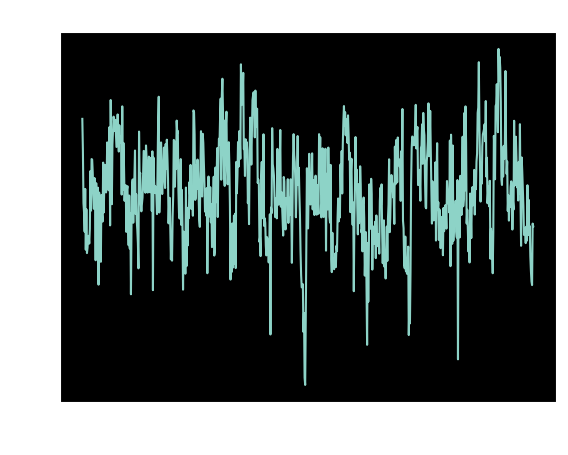

In [6]:
# Plotter la série temporelle
plt.figure()
plt.style.use("dark_background")
s.plot()
plt.title("Southern Oscillation Index")
plt.xlabel("indice standardisé de SOI")
plt.ylabel("indice de temps")
plt.show()

Le SOI mesure comment la pression de l'air varie entre Tahiti et Darwin : 
- Autour de 0, la pression est neutre. 
- Quand l’écart de pression est plus grand que la normale → on est en tendance La Niña.
- Quand l’écart est plus petit que la normale (ou inversé) → on est en tendance El Niño.

Vu que c'est une variable temporelle de croissance, la tendance elle est constante. 

# 2. Choisir le nombre de retards optimal par l'analyse de l'autocorrélation

In [7]:
# Test de stationnarité
s_adfuller = adfuller(s)
print(s_adfuller)
s_adfuller_p_value = s_adfuller[1]
print(s_adfuller_p_value)
if s_adfuller_p_value < 0.05 : 
    print("on rejette H0, la série est stationnaire")
else : 
    print("il n'y a pas suffisamment de preuve pour rejetter H0")

(np.float64(-7.502543292317648), np.float64(4.21630297019212e-11), 2, 777, {'1%': np.float64(-3.4387940607132887), '5%': np.float64(-2.8652669182555943), '10%': np.float64(-2.5687545755297494)}, np.float64(1610.2252214204245))
4.21630297019212e-11
on rejette H0, la série est stationnaire


Nous pouvons donc passer à l'analyse de l'autocorrélation

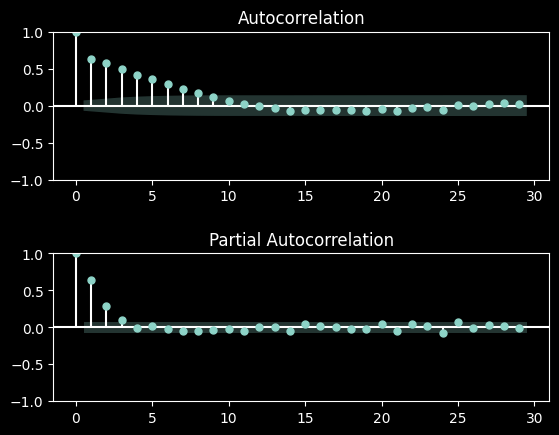

In [8]:
# ACF et PACF
fig = plt.figure()
ax1 = fig.add_subplot(2,1,1)
plot_acf(s, ax=ax1) 
ax2 = fig.add_subplot(2,1,2)
plot_pacf(s, ax=ax2)
plt.subplots_adjust(hspace=0.5)
plt.show()

L'autoccorélation mesure l'intensité de relation entre le lags. Le partical autocorrélation mesure toujours cette intensité mais corrigé des cumuls des autres relations. 

Nous venons de voir que la série temporelle présente environ 09 nombre de retards qui sont liés entre eux. Ce qui signifie qu'un modèle auto-régressif est idéal pour modéliser SOI. Le nombre retards optimal peut être entre 1 à 4. 

Il faut donc utiliser des modèles auto-régressifs. Mais vu que la série est directement stationnaire, nous n'intégrons pas le facteur (I) : nombre de différenciations pour rendre la série stationnaire. 

Faut-il intégrer alors le processus Moving Average (MA) ? Normalement, çà n'apporte rien puisque ACF qui décroît progressivement et une PACF qui coupe net après le lag 1 → c’est la signature d’un AR(p), pas d’un MA. Nous allons quand même expérimenter, nous verrons les résultats finaux. Mais avec q de MA faible.

Il faut donc essayer et comprarer les modèles basiques suivants : 
- AR (p)
- ARMA (p, qm)
- ARCH (qv)
- GARCH (p, qv)

# Split des données et préparation des paramètres

In [9]:
print(s.dtype)

float64


In [90]:
y = pd.Series(s , dtype=float).dropna()
n = len(y)
h = 0.7 * n
h = int(h)
y_train, y_test = s.iloc[:h], s.iloc[h:]
idx_train, idx_test = y_train.index, y_test.index
pmax = 9 # p_max représente la valeur maximale de retards pris par le modèle. Elle ne dépasse pas 9 selon le l'analyse de ACF et PACF
k = 5 # Nombre d'échantillon de backtesting

In [94]:
print(len(y_train))
print(len(y_test))

546
234


# Modèle AR()

## Choix de p Avec AIC

In [95]:
res_aic_best = float("inf")
p_aic_optimal = None 

for p in range(1, pmax + 1):
    mod = ARIMA(endog=y_train, order=(p, 0, 0))
    res = mod.fit()
    
    if res.aic < res_aic_best:   # on garde le meilleur
        res_aic_best = res.aic
        p_aic_optimal = p

print(f"Meilleur p : {p_aic_optimal} avec AIC = {res_aic_best}")

Meilleur p : 3 avec AIC = 1141.754619257801


## Choix de p avec BIC

In [96]:
res_bic_best = float("inf")
p_bic_optimal = None 

for p in range(1, pmax + 1):
    mod = ARIMA(endog=y_train, order=(p, 0, 0))
    res = mod.fit()
    
    if res.bic < res_bic_best:   # on garde le meilleur selon BIC
        res_bic_best = res.bic
        p_bic_optimal = p

print(f"Meilleur p : {p_bic_optimal} avec BIC = {res_bic_best}")


Meilleur p : 2 avec BIC = 1163.1127480916539


## Choix de p avec RMSE

In [97]:
# Etablir une fonction de Backtesting pour le choix de p dans AR(p)
def ts_backtesting (s, pmax, nchunks) :
    s = pd.Series(s).dropna()
    n = len(s)
    cuts = np.linspace(0, n , nchunks + 1, dtype = int) # Puisque iloc en bas exige un float
    results = []

    for k in range ( nchunks - 1 ) : 
        for p in range (1 , pmax + 1) : 
            train = s.iloc[:cuts[k+1]]
            validation = s.iloc[cuts[k+1]:cuts[k+2]]

            try : 
                mod = ARIMA(train, order = (p,0,0))
                res = mod.fit()

                forecast_values = pd.Series(res.forecast(steps = len(validation)))
                forecast = pd.Series(forecast_values, index=validation.index)
                rmse_fold = np.sqrt(((validation - forecast) ** 2).mean())
                
                results.append((p, rmse_fold))
        
            except Exception : 
                results.append((p, np.nan))

    df_results = pd.DataFrame(results, columns=["p", "rmse"])
    return df_results.groupby("p")["rmse"].mean()

In [98]:
# Appeler la fonction de Backtesting
ts_backtesting(y_train, pmax=pmax, nchunks = 5)

p
1    0.945341
2    0.944716
3    0.945502
4    0.946386
5    0.947320
6    0.946135
7    0.944562
8    0.943300
9    0.942459
Name: rmse, dtype: float64

AR(p) -> AIC : p = 3, BIC : p = 2 , RMSE : p = 9

# ARMA (p, qm)

## Choix de p Avec AIC

In [99]:
res_aic_best = float("inf")
p_aic_optimal = None 
qmmax = 3 

for p in range(1, pmax + 1):
    for q in range(1, qmmax + 1) : 
        mod = ARIMA(endog=y_train, order=(p, 0, q))
        res = mod.fit()
    
        if res.aic < res_aic_best:   # on garde le meilleur
            res_aic_bestc = res.aic
            p_aic_optimal = p

print(f"Meilleur p : {res_aic_best} avec AIC = {p_aic_optimal}")

d:\Portofolio Data science\Time Series\Travaux pratiques Bases\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\Portofolio Data science\Time Series\Travaux pratiques Bases\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
d:\Portofolio Data science\Time Series\Travaux pratiques Bases\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\Portofolio Data science\Time Series\Travaux pratiques Bases\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: Us

Meilleur p : inf avec AIC = 9


d:\Portofolio Data science\Time Series\Travaux pratiques Bases\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


La modèle ne converge pas. Ce qui a été attendu puisque le processus MA n'est pas présent dans la série temporelle, d'après notre interprétation de ACF et PACF ci-dessus.

Dans un test de plusieurs modèles dans un processus de Big Data, il faut toujours prévenir un processus de gestion d'arrêt automatique des modèles comme le cas ici. 

Nous allons délaisser donc notre expérimentation.

# G(ARCH)

## AIC

In [100]:
res_aic_best = float("inf")
p_aic_optimal = None 
q_aic_optimal = None
qvmax = 3

for p in range(1, pmax + 1):
    for q in range(1, qvmax + 1) :
        mod = arch_model(y_train, mean="Zero", vol="GARCH", p=p, q=q, dist="normal")
        res = mod.fit(disp="off")
    
        if res.aic < res_aic_best:   # on garde le meilleur
            res_aic_best = res.aic
            p_aic_optimal = p
            q_aic_optimal = q
        

print(f"Meilleur (p, q) : ({p_aic_optimal},{q_aic_optimal}) avec AIC = {res_aic_best}")

Meilleur (p, q) : (1,1) avec AIC = 1380.8128587711553


## BIC

In [101]:
res_bic_best = float("inf")
p_bic_optimal = None
q_bic_optimal = None
qvmax = 3  # borne supérieure pour q

for p in range(1, pmax + 1):
    for q in range(1, qvmax + 1):
        mod = arch_model(y_train, mean="Zero", vol="GARCH", p=p, q=q, dist="normal")
        res = mod.fit(disp="off")

        if res.bic < res_bic_best:   # comparaison sur le BIC
            res_bic_best = res.bic
            p_bic_optimal = p
            q_bic_optimal = q

print(f"Meilleur (p, q) : ({p_bic_optimal},{q_bic_optimal}) avec BIC = {res_bic_best}")


Meilleur (p, q) : (1,1) avec BIC = 1393.72071569839


## RMSE

In [102]:
def garch_backtesting(r, pmax=3, qmax=3, nchunks=5,
                      mean="Zero", dist="normal"):
    """
    Backtesting pour trouver la meilleure combinaison (p,q) dans un modèle GARCH,
    en minimisant la RMSE des prévisions de variance sur les folds de validation.
    """
    r = pd.Series(r).astype(float).dropna()
    n = len(r)
    cuts = np.linspace(0, n, nchunks + 1, dtype=int)
    results = []

    def rmse_loss(y, h):
        return np.sqrt(np.mean((y**2 - h)**2))

    for k in range(nchunks - 1):
        train = r.iloc[:cuts[k+1]]
        val   = r.iloc[cuts[k+1]:cuts[k+2]]
        if val.empty:
            continue

        for p in range(1, pmax + 1):
            for q in range(1, qmax + 1):
                try:
                    am = arch_model(train, mean=mean, vol="GARCH", p=p, q=q, dist=dist)
                    res = am.fit(disp="off")

                    # Prévision de la variance conditionnelle
                    fc = res.forecast(horizon=len(val), reindex=False)
                    h_val = fc.variance.values[-1, :]

                    score = rmse_loss(val.values, h_val)
                    results.append((p, q, score))

                except Exception:
                    results.append((p, q, np.nan))

    if not results:
        raise ValueError("Aucun résultat valide : vérifie la taille de la série ou nchunks.")

    df = pd.DataFrame(results, columns=["p", "q", "rmse"])
    mean_rmse = df.groupby(["p", "q"], as_index=True)["rmse"].mean()

    best_pq = mean_rmse.idxmin()
    best_score = mean_rmse.min()

    best_idx = (int(best_pq[0]), int(best_pq[1]))

    return mean_rmse.sort_values(), best_idx, best_score

In [103]:
# Appeler la fonction de Backtesting pour un GARCH(p,q)
scores, best_idx, best_score = garch_backtesting(
    y_train,
    pmax=pmax,
    qmax=qvmax,
    nchunks=5
)

print(f"Meilleure combinaison (p,q) = {best_idx} avec RMSE = {best_score:.4f}")

Meilleure combinaison (p,q) = (1, 2) avec RMSE = 1.3990


# RéEntrainement des modèles sur l'ensemble de l'échantillon d'entrainement 

In [104]:
# AR(p)
model_ar_p9 = ARIMA(endog=y_train, order=(9,0,0))
res_ar_p9 = model_ar_p9.fit()
resid_ar_p9 = res_ar_p9.resid

model_ar_p3 = ARIMA(endog=y_train, order=(3,0,0))
res_ar_p3 = model_ar_p3.fit()
resid_ar_p3 = res_ar_p3.resid

model_ar_p2 = ARIMA(endog=y_train, order=(2,0,0))
res_ar_p2 = model_ar_p2.fit()
resid_ar_p2 = res_ar_p2.resid

In [105]:
# GARCH(p,q)
model_garch_p1_q1 = arch_model(y_train, mean= "Zero", vol="GARCH", p=1, q=1, dist="normal")
res_garch_p1_q1 = model_garch_p1_q1.fit(disp="off")
resid_garch_p1_q1 = res_garch_p1_q1.resid

model_garch_p7_q1 = arch_model(y_train, mean= "Zero", vol="GARCH", p=7, q=1, dist="normal")
res_garch_p7_q1 = model_garch_p7_q1.fit(disp="off")
resid_garch_p7_q1 = res_garch_p7_q1.resid

# Validation des modèles

## Analyse de l'auto-corrélation

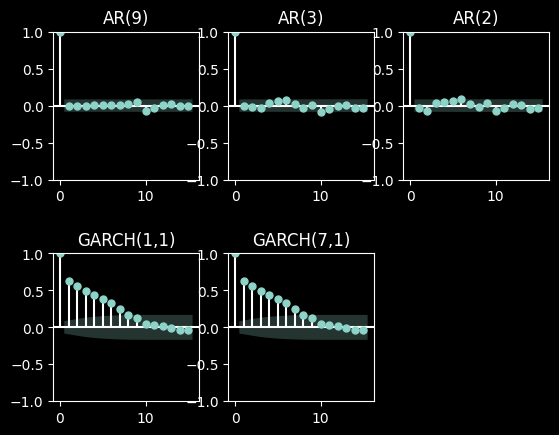

In [106]:
fig = plt.figure()
plt.style.use("dark_background")

#AR(p)
ax1 = fig.add_subplot(2,3,1)
plot_acf(resid_ar_p9, lags = 15 , ax=ax1)
plt.title("AR(9)")
ax2 = fig.add_subplot(2,3,2)
plot_acf(resid_ar_p3, lags = 15, ax=ax2)
plt.title("AR(3)")
ax3 = fig.add_subplot(2,3,3)
plot_acf(resid_ar_p2, lags = 15, ax=ax3)
plt.title("AR(2)")

# GARCH(p,q)
ax4 = fig.add_subplot(2,3,4)
plot_acf(resid_garch_p1_q1, lags = 15 , ax=ax4)
plt.title("GARCH(1,1)")
ax5 = fig.add_subplot(2,3,5)
plot_acf(resid_garch_p7_q1, lags = 15 , ax=ax5)
plt.title("GARCH(7,1)")


plt.subplots_adjust(hspace=0.5)

plt.show()

## Analyse des hypothèses sur les résidus

In [107]:
def test_residus(models, lags=10, alpha=0.05):
    """
    models : dict {nom: résidus ou objet avec .resid}
    lags   : int  (dernier retard testé pour Ljung-Box)
    alpha  : seuil de décision
    """
    results = []

    for name, obj in models.items():
        # Récupérer les résidus
        r = obj.resid if hasattr(obj, "resid") else obj
        r = np.asarray(r).ravel()
        r = r[~np.isnan(r)]

        # Ljung–Box
        lb = acorr_ljungbox(r, lags=[lags], return_df=True)
        lb_p = lb["lb_pvalue"].iloc[0]

        # Jarque–Bera
        jb_stat, jb_p, skew, kurt = jarque_bera(r)

        blanc_ok = lb_p > alpha
        normal_ok = jb_p > alpha

        results.append({
            "modele": name,
            "n": len(r),
            "lb_pvalue": lb_p,
            "jb_pvalue": jb_p,
            "blanc": blanc_ok,
            "normal": normal_ok,
        })

        # Affichage
        print(f"\n=== {name} ===")
        print(f"Ljung-Box (lag {lags}) : p = {lb_p:.3f} → {'OK' if blanc_ok else 'Autocorrélé'}")
        print(f"Jarque-Bera            : p = {jb_p:.3f} → {'OK' if normal_ok else 'Non normal'}")

        # Conclusion
        if blanc_ok and normal_ok:
            print("→ Conclusion : Résidus OK (bruit blanc et normaux).")
        elif blanc_ok and not normal_ok:
            print("→ Conclusion : Résidus blancs mais non normaux.")
        elif not blanc_ok and normal_ok:
            print("→ Conclusion : Résidus normaux mais autocorrélés.")
        else:
            print("→ Conclusion : Résidus problématiques (autocorrélés et non normaux).")

    return pd.DataFrame(results).set_index("modele")

In [108]:
# Dictionnaire des modèles et de leurs résidus
models = {
    "AR(9)"      : resid_ar_p9,
    "AR(3)"      : resid_ar_p3,
    "AR(2)"      : resid_ar_p2,
    "GARCH(1,1)" : resid_garch_p1_q1,
    "GARCH(7,1)" : resid_garch_p7_q1,
}

# Lancer les tests
summary = test_residus(models, lags=10, alpha=0.05)

# Afficher un tableau récapitulatif
print("\n=== Résumé global ===")
print(summary[["lb_pvalue","jb_pvalue","blanc","normal"]])


=== AR(9) ===
Ljung-Box (lag 10) : p = 0.920 → OK
Jarque-Bera            : p = 0.461 → OK
→ Conclusion : Résidus OK (bruit blanc et normaux).

=== AR(3) ===
Ljung-Box (lag 10) : p = 0.319 → OK
Jarque-Bera            : p = 0.653 → OK
→ Conclusion : Résidus OK (bruit blanc et normaux).

=== AR(2) ===
Ljung-Box (lag 10) : p = 0.100 → OK
Jarque-Bera            : p = 0.674 → OK
→ Conclusion : Résidus OK (bruit blanc et normaux).

=== GARCH(1,1) ===
Ljung-Box (lag 10) : p = 0.000 → Autocorrélé
Jarque-Bera            : p = 0.000 → Non normal
→ Conclusion : Résidus problématiques (autocorrélés et non normaux).

=== GARCH(7,1) ===
Ljung-Box (lag 10) : p = 0.000 → Autocorrélé
Jarque-Bera            : p = 0.000 → Non normal
→ Conclusion : Résidus problématiques (autocorrélés et non normaux).

=== Résumé global ===
                lb_pvalue  jb_pvalue  blanc  normal
modele                                             
AR(9)        9.199452e-01   0.461317   True    True
AR(3)        3.191081e-01   

Les modèles AR(p) sont bien spécifiés. Par contre, les modèles GARCH(p,q) ne capturent pas l'autocorrélation. 

Normalement, GARCH ne peut être utilisé dans le test. Cependant, pour notre curiosité, essayons de le tester quand même. 

On attend donc que GARCH performe moins que AR(p).

# Test

## AR(p)

In [109]:
# 1) Prévision à 1 pas (inchangé)
def forecast_one_step(results, *, alpha=0.05, exog_fc=None):
    fc = results.get_forecast(steps=1, exog=exog_fc)
    yhat = fc.predicted_mean.iloc[0]
    ci = fc.conf_int(alpha=alpha).iloc[0]
    lower, upper = ci.iloc[0], ci.iloc[1]
    idx_target = fc.predicted_mean.index[0]
    return yhat, lower, upper, idx_target

In [110]:
# 2) Exog à ts (inchangé)
def exog_row_at(exog, ts):
    if exog is None:
        return None
    if isinstance(exog, pd.DataFrame):
        return exog.loc[[ts]]
    if isinstance(exog, pd.Series):
        return pd.DataFrame([exog.loc[ts]], index=[ts])
    return None

In [111]:
# 3) Append observation (inchangé)
def append_observation(results, ts, y_true):
    endog_name = results.model.endog_names
    new_obs = pd.Series([y_true], index=[ts], name=endog_name)
    return results.append(new_obs, refit=False)

# --- petit utilitaire pour décaler l'index de sortie ---
def _apply_index_shift(idx, pred_index_shift):
    if pred_index_shift is None:
        return idx
    
    # Cas index numérique (int ou numpy int)
    if isinstance(idx, (int, np.integer)):
        return idx - int(pred_index_shift)  # ex: pred_index_shift=1
    
    # Cas index temporel (Timestamp / DateOffset)
    if isinstance(idx, (pd.Timestamp, pd.DatetimeIndex)):
        if not isinstance(pred_index_shift, (pd.Timedelta, pd.DateOffset)):
            pred_index_shift = pd.Timedelta(pred_index_shift)
        return idx - pred_index_shift
    
    # Sinon on renvoie inchangé
    return idx


In [112]:
# 4) Boucle rolling — AJOUT de pred_index_shift
def rolling_loop(
    results,
    y_test,
    *,
    alpha=0.05,
    exog=None,
    use_pred_index=True,
    pred_index_shift=None,   # <<--- NOUVEAU
):
    y_test = y_test.sort_index().dropna()

    updated = results
    yhat_list, low_list, up_list, idx_list = [], [], [], []

    for ts, y_true in y_test.items():
        exog_fc = exog_row_at(exog, ts)

        # (a) prévoir 1 pas
        yhat, lower, upper, idx_target = forecast_one_step(updated, alpha=alpha, exog_fc=exog_fc)

        # (b) choisir l'index de sortie (t+1 ou t), puis appliquer le décalage si demandé
        idx_out = idx_target if use_pred_index else ts
        idx_out = _apply_index_shift(idx_out, pred_index_shift)

        # (c) stocker
        idx_list.append(idx_out)
        yhat_list.append(yhat); low_list.append(lower); up_list.append(upper)

        # (d) mise à jour avec la vraie obs à t
        exog_t = exog_row_at(exog, ts)
        if exog_t is None:
            updated = append_observation(updated, ts, y_true)
        else:
            endog_name = updated.model.endog_names
            new_obs = pd.Series([y_true], index=[ts], name=endog_name)
            updated = updated.append(new_obs, exog=exog_t, refit=False)

    preds_df = pd.DataFrame(
        {"yhat": yhat_list, "lower": low_list, "upper": up_list},
        index=pd.Index(idx_list, name=y_test.index.name),
    )
    return preds_df, updated

In [113]:
# 5) Batch — on propage le paramètre
def rolling_batch(
    models: dict,
    y_test,
    *,
    alpha=0.05,
    exog=None,
    use_pred_index=True,
    pred_index_shift=None,   # <<--- NOUVEAU
):
    preds, updated = {}, {}
    for name, res in models.items():
        df, up = rolling_loop(
            res,
            y_test,
            alpha=alpha,
            exog=exog,
            use_pred_index=use_pred_index,
            pred_index_shift=pred_index_shift,   # <<--- propage
        )
        preds[name] = df
        updated[name] = up
    return preds, updated

In [114]:
# --- Lancer le rolling avec décalage d'un pas (index entiers) ---
preds_dict, updated_dict = rolling_batch(
    models_to_test,
    y_test_clean,
    alpha=0.05,
    exog=None,
    use_pred_index=True,
    pred_index_shift=1   # décalage d'un pas car index = entiers
)

def mae(y, yhat):  return np.mean(np.abs(y - yhat))
def rmse(y, yhat): return np.sqrt(np.mean((y - yhat) ** 2))
def mape(y, yhat):
    y = np.asarray(y); yhat = np.asarray(yhat)
    return np.nanmean(np.abs((y - yhat) / np.where(y == 0, np.nan, y))) * 100

metrics_rows = []
for name, dfp in preds_dict.items():
    # réaligner la vérité terrain
    y_true_on_predidx = y_test_clean.reindex(dfp.index).dropna()
    dfp = dfp.loc[y_true_on_predidx.index]

    if len(dfp) == 0:
        metrics_rows.append({
            "model": name, "n_eval": 0,
            "MAE": np.nan, "RMSE": np.nan, "MAPE": np.nan,
            "IC95_coverage": np.nan
        })
        continue

    metrics_rows.append({
        "model": name,
        "n_eval": len(y_true_on_predidx),
        "MAE":  mae(y_true_on_predidx.values, dfp["yhat"].values),
        "RMSE": rmse(y_true_on_predidx.values, dfp["yhat"].values),
        "MAPE": mape(y_true_on_predidx.values, dfp["yhat"].values),
        "IC95_coverage": float(np.mean(
            (y_true_on_predidx.values >= dfp["lower"].values) &
            (y_true_on_predidx.values <= dfp["upper"].values)
        )),
    })

metrics_df = pd.DataFrame(metrics_rows).set_index("model").sort_values("RMSE")
print("\n=== Résumé métriques (aligné sur t) ===")
print(metrics_df)


=== Résumé métriques (aligné sur t) ===
       n_eval       MAE      RMSE        MAPE  IC95_coverage
model                                                       
AR(3)     545  0.419162  0.529203   91.574833       0.981651
AR(2)     545  0.418957  0.532457  100.177296       0.983486
AR(9)     545  0.427756  0.541949  103.825755       0.983486


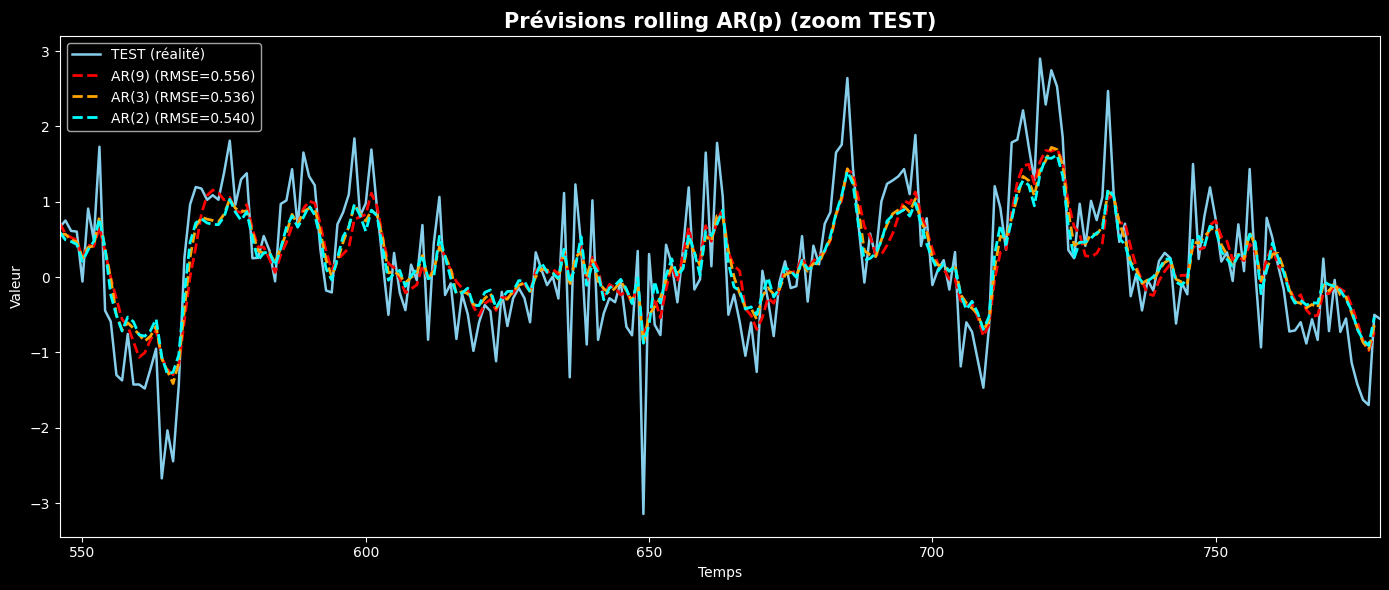

In [ ]:
plt.style.use("dark_background")
plt.figure(figsize=(14,6))

# --- TEST en bleu clair ---
plt.plot(y_test.index, y_test.values,
         color="skyblue", linewidth=1.8, label="TEST (réalité)")

# --- Boucle sur les modèles AR(p) ---
colors = {"AR(2)": "cyan", "AR(3)": "orange", "AR(9)": "red"}  # couleurs personnalisables
for name, dfp in preds_dict.items():
    if name.startswith("AR("):
        y_true_on_predidx = y_test.sort_index().reindex(dfp.index).dropna()
        dfp = dfp.loc[y_true_on_predidx.index]
        rmse_val = np.sqrt(np.mean((y_true_on_predidx - dfp["yhat"])**2))

        plt.plot(dfp.index, dfp["yhat"].values,
                 color=colors.get(name, "white"),
                 linestyle="--", linewidth=2,
                 label=f"{name} (RMSE={rmse_val:.3f})")

# --- Limite au test ---
plt.xlim(y_test.index.min(), y_test.index.max())

# --- Titres et légende ---
plt.title("Prévisions rolling AR(p) (zoom TEST)", fontsize=15, weight="bold")
plt.xlabel("Temps")
plt.ylabel("Valeur")
plt.legend(loc="upper left", facecolor="black")
plt.tight_layout()
plt.show()

# Choix de modèle final : 
## Explication des métriques : 
- MAE (Mean Absolute Error) : erreur absolue moyenne, indique l’écart moyen entre prévisions et réalité.

- RMSE (Root Mean Squared Error) : racine de l’erreur quadratique moyenne, pénalise davantage les grosses erreurs.

- MAPE (Mean Absolute Percentage Error) : erreur moyenne en pourcentage, mesure la précision relative.

## AR(3)
Dans nos résultats, AR(3) présente le plus faible RMSE et MAPE, avec un MAE comparable à AR(2). Il est donc le modèle le plus précis et robuste. Il est aussi simple. Ce qui justifie son choix final.